# 02 - Overfitting, Underfitting, and K-Fold Cross-Validation

This notebook explores the fundamental bias-variance trade-off in neural networks, demonstrates **overfitting** empirically, and implements **K-Fold Cross-Validation** in PyTorch.

---

## Key Topics:

1. **Understanding Overfitting**: High capacity model + small/noisy dataset.
2. **Empirical Overfitting Demonstration**: Tracking divergence between training and validation loss curves.
3. **K-Fold Cross-Validation in PyTorch**:
   - Integrating `scikit-learn` `KFold` with PyTorch `DataLoader` & `Subset`.
   - Per-fold training and validation pipeline.
4. **Metrics Aggregation**: Mean and standard deviation across K folds.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as torch_optim
from torch.utils.data import TensorDataset, DataLoader, Subset

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
torch.manual_seed(42)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')


## 1. Creating an Overfitting Scenario

To force overfitting, we generate a small, noisy synthetic dataset (only 100 samples) and fit a high-capacity deep neural network (4 hidden layers, 128 units each, no regularization) for 250 epochs.


In [3]:
# Small, noisy dataset (100 samples total)
X_small, y_small = make_classification(
    n_samples=100,
    n_features=30,
    n_informative=10,
    n_redundant=10,
    n_classes=2,
    flip_y=0.2, # 20% noise in labels
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(X_small, y_small, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)

X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val_s, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

# High-Capacity Complex Model
class HighCapacityANN(nn.Module):
    def __init__(self, input_dim=30):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )
    def forward(self, x):
        return self.net(x)

overfit_model = HighCapacityANN(input_dim=30)
criterion = nn.CrossEntropyLoss()
optimizer = torch_optim.Adam(overfit_model.parameters(), lr=0.002)

# Train high-capacity model
train_losses, val_losses = [], []
train_accs, val_accs = [], []

epochs = 250
for epoch in range(1, epochs + 1):
    overfit_model.train()
    optimizer.zero_grad()
    out = overfit_model(X_train_t)
    loss = criterion(out, y_train_t)
    loss.backward()
    optimizer.step()
    
    train_loss = loss.item()
    train_pred = torch.argmax(out, dim=1)
    train_acc = (train_pred == y_train_t).float().mean().item()
    
    overfit_model.eval()
    with torch.no_grad():
        val_out = overfit_model(X_val_t)
        v_loss = criterion(val_out, y_val_t).item()
        val_pred = torch.argmax(val_out, dim=1)
        v_acc = (val_pred == y_val_t).float().mean().item()
        
    train_losses.append(train_loss)
    val_losses.append(v_loss)
    train_accs.append(train_acc)
    val_accs.append(v_acc)


## 2. Visualizing Overfitting Curves

Notice how after ~40 epochs, the training loss continues to drop toward 0 (100% train accuracy memorization), while the validation loss rises sharply—classic hallmark of **overfitting**.


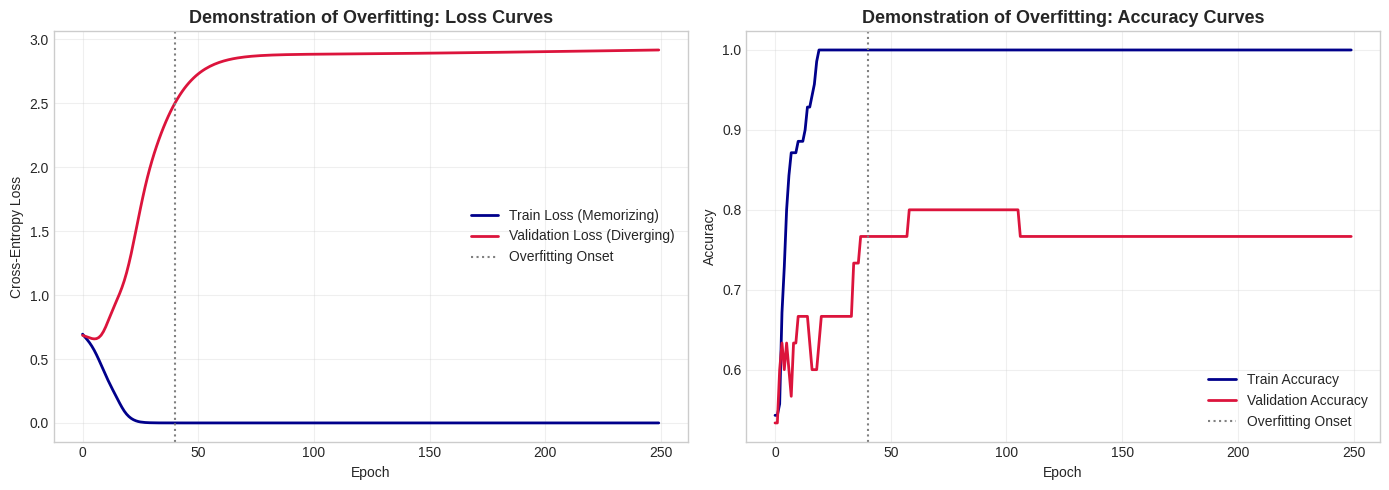

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(train_losses, label='Train Loss (Memorizing)', color='darkblue', linewidth=2)
axes[0].plot(val_losses, label='Validation Loss (Diverging)', color='crimson', linewidth=2)
axes[0].axvline(x=40, color='gray', linestyle=':', label='Overfitting Onset')
axes[0].set_title('Demonstration of Overfitting: Loss Curves', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(train_accs, label='Train Accuracy', color='darkblue', linewidth=2)
axes[1].plot(val_accs, label='Validation Accuracy', color='crimson', linewidth=2)
axes[1].axvline(x=40, color='gray', linestyle=':', label='Overfitting Onset')
axes[1].set_title('Demonstration of Overfitting: Accuracy Curves', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 3. Implementing K-Fold Cross-Validation in PyTorch

Cross-validation evaluates generalization ability robustly by splitting data into $K$ equal folds. For each fold:

1. $K-1$ folds are used for training.
2. $1$ fold is held out for validation.
3. Model weights are re-initialized from scratch.


In [5]:
# Re-scaling full small dataset for K-Fold
X_full_scaled = scaler.fit_transform(X_small)
full_dataset = TensorDataset(
    torch.tensor(X_full_scaled, dtype=torch.float32),
    torch.tensor(y_small, dtype=torch.long)
)

K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42)

fold_results = []

for fold, (train_idx, val_idx) in enumerate(kf.split(full_dataset), start=1):
    # Create Subsets for current fold
    train_sub = Subset(full_dataset, train_idx)
    val_sub = Subset(full_dataset, val_idx)
    
    loader_train = DataLoader(train_sub, batch_size=16, shuffle=True)
    loader_val = DataLoader(val_sub, batch_size=16, shuffle=False)
    
    # Re-instantiate clean model for each fold
    fold_model = nn.Sequential(
        nn.Linear(30, 32),
        nn.ReLU(),
        nn.Linear(32, 16),
        nn.ReLU(),
        nn.Linear(16, 2)
    )
    
    fold_criterion = nn.CrossEntropyLoss()
    fold_optimizer = torch_optim.Adam(fold_model.parameters(), lr=0.005)
    
    # Train for 60 epochs on this fold
    for epoch in range(60):
        fold_model.train()
        for bx, by in loader_train:
            fold_optimizer.zero_grad()
            out = fold_model(bx)
            loss = fold_criterion(out, by)
            loss.backward()
            fold_optimizer.step()
            
    # Evaluate on validation fold
    fold_model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for bx, by in loader_val:
            out = fold_model(bx)
            loss = fold_criterion(out, by)
            val_loss += loss.item() * bx.size(0)
            preds = torch.argmax(out, dim=1)
            correct += (preds == by).sum().item()
            total += by.size(0)
            
    final_val_loss = val_loss / total
    final_val_acc = correct / total
    
    fold_results.append({'fold': fold, 'val_loss': final_val_loss, 'val_acc': final_val_acc})
    print(f"Fold {fold}/{K} | Val Loss: {final_val_loss:.4f} | Val Accuracy: {final_val_acc:.4f}")


Fold 1/5 | Val Loss: 1.1768 | Val Accuracy: 0.7000
Fold 2/5 | Val Loss: 1.5106 | Val Accuracy: 0.7500
Fold 3/5 | Val Loss: 3.2622 | Val Accuracy: 0.5000
Fold 4/5 | Val Loss: 3.9342 | Val Accuracy: 0.5500
Fold 5/5 | Val Loss: 1.1005 | Val Accuracy: 0.7000


## 4. Aggregating Cross-Validation Results

We compute mean cross-validation accuracy $\mu$ and standard deviation $\sigma$ across folds to measure variance.


K-Fold CV Results (5 Folds):
Mean Validation Accuracy: 64.00% (+/- 9.70%)
Mean Validation Loss:     2.1969


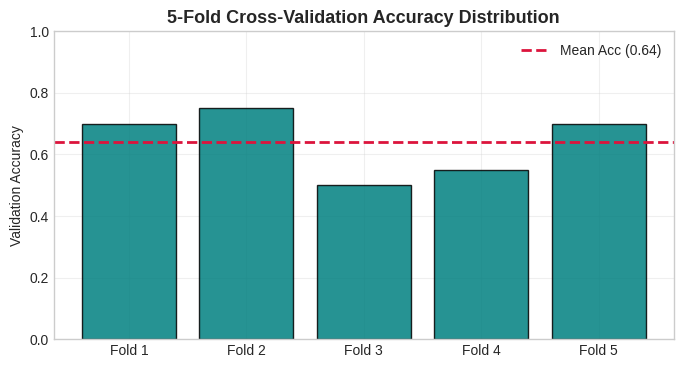

In [6]:
accs = [r['val_acc'] for r in fold_results]
losses = [r['val_loss'] for r in fold_results]

mean_acc = np.mean(accs)
std_acc = np.std(accs)
mean_loss = np.mean(losses)

print("=" * 50)
print(f"K-Fold CV Results ({K} Folds):")
print(f"Mean Validation Accuracy: {mean_acc * 100:.2f}% (+/- {std_acc * 100:.2f}%)")
print(f"Mean Validation Loss:     {mean_loss:.4f}")
print("=" * 50)

# Visualizing Fold Accuracies
plt.figure(figsize=(8, 4))
bars = plt.bar([f"Fold {r['fold']}" for r in fold_results], accs, color='teal', alpha=0.85, edgecolor='black')
plt.axhline(y=mean_acc, color='crimson', linestyle='--', linewidth=2, label=f'Mean Acc ({mean_acc:.2f})')
plt.title(f'{K}-Fold Cross-Validation Accuracy Distribution', fontsize=13, fontweight='bold')
plt.ylabel('Validation Accuracy')
plt.ylim(0.0, 1.0)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
